DAY 14 — Pandas Gaps

TOPIC 1 — melt()

Imagine you have this DataFrame — called wide format because each subject is its own column

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    "name": ["Tony", "Pepper", "Rhodey"],
    "math": [85, 92, 78],
    "science": [90, 88, 82],
    "english": [78, 85, 90]
})

print(df)


     name  math  science  english
0    Tony    85       90       78
1  Pepper    92       88       85
2  Rhodey    78       82       90


This is great for reading but bad for many Pandas operations — like plotting all subjects together or grouping by subject.
* melt() converts it to long format — each row is one student-subject combination

In [3]:
melted = df.melt(
    id_vars="name",       # column to keep as identifier
    var_name="subject",   # name for the new column holding old column names
    value_name="marks"    # name for the new column holding values
)
print(melted)


     name  subject  marks
0    Tony     math     85
1  Pepper     math     92
2  Rhodey     math     78
3    Tony  science     90
4  Pepper  science     88
5  Rhodey  science     82
6    Tony  english     78
7  Pepper  english     85
8  Rhodey  english     90


subject
english    84.333333
math       85.000000
science    86.666667
Name: marks, dtype: float64


<Axes: xlabel='subject', ylabel='marks'>

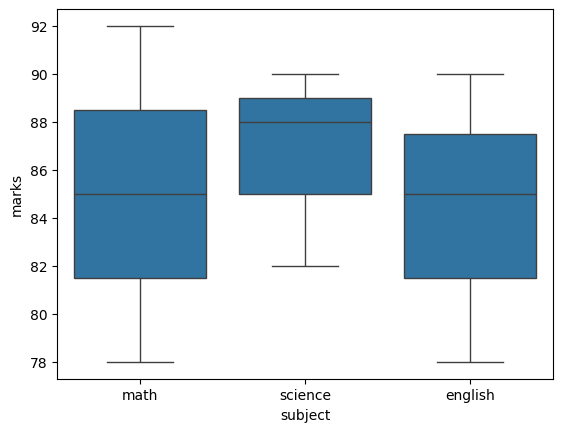

In [ ]:
# Average marks per subject — impossible in wide format easily
print(melted.groupby("subject")["marks"].mean())

# Plot all subjects together with hue
sns.boxplot(x="subject", y="marks", data=melted)
plt.show()

TOPIC 2 — merge()

merge() combines two DataFrames based on a common column — exactly like SQL JOIN

In [4]:
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4],
    "name": ["Tony", "Pepper", "Rhodey", "Happy"],
    "branch": ["AIML", "CSE", "ECE", "MECH"]
})

marks = pd.DataFrame({
    "student_id": [1, 2, 3, 5],
    "math": [85, 92, 78, 88],
    "science": [90, 88, 82, 91]
})

# Inner join — only students present in BOTH DataFrames
inner = pd.merge(students, marks, on="student_id", how="inner")
print(inner)
# Only Tony, Pepper, Rhodey — Happy(4) not in marks, student 5 not in students

# Left join — all students, marks filled with NaN if missing
left = pd.merge(students, marks, on="student_id", how="left")
print(left)
# All 4 students — Happy gets NaN for marks

# Right join — all marks records, student info NaN if missing
right = pd.merge(students, marks, on="student_id", how="right")
print(right)
# Students 1,2,3 get info — student 5 gets NaN for name/branch

# Outer join — everything from both, NaN where missing
outer = pd.merge(students, marks, on="student_id", how="outer")
print(outer)

   student_id    name branch  math  science
0           1    Tony   AIML    85       90
1           2  Pepper    CSE    92       88
2           3  Rhodey    ECE    78       82
   student_id    name branch  math  science
0           1    Tony   AIML  85.0     90.0
1           2  Pepper    CSE  92.0     88.0
2           3  Rhodey    ECE  78.0     82.0
3           4   Happy   MECH   NaN      NaN
   student_id    name branch  math  science
0           1    Tony   AIML    85       90
1           2  Pepper    CSE    92       88
2           3  Rhodey    ECE    78       82
3           5     NaN    NaN    88       91
   student_id    name branch  math  science
0           1    Tony   AIML  85.0     90.0
1           2  Pepper    CSE  92.0     88.0
2           3  Rhodey    ECE  78.0     82.0
3           4   Happy   MECH   NaN      NaN
4           5     NaN    NaN  88.0     91.0


In real ML projects you almost always have data in multiple files — merge() is how you combine them. You'll use inner and left joins most often.

🧠 TOPIC 3 — pivot_table()

pivot_table() is groupby() on steroids. It lets you summarize data across two dimensions at once — like a spreadsheet pivot table.

In [7]:
df = pd.DataFrame({
    "name": ["Tony", "Pepper", "Rhodey", "Happy", "Tony", "Pepper"],
    "subject": ["math", "math", "math", "science", "science", "science"],
    "marks": [85, 92, 78, 88, 90, 85],
    "semester": [1, 1, 1, 2, 2, 2]
})

# Average marks per student per subject
pivot = df.pivot_table(
    values="marks",        # what to calculate
    index="name",          # rows
    columns="subject",     # columns
    aggfunc="mean"         # how to aggregate
)

# Count, sum, max, min, or even multiple at once
pivot2 = df.pivot_table(
    values="marks",
    index="name",
    columns="subject",
    aggfunc=["mean", "max"]
)

print(pivot)
print(pivot2)


subject  math  science
name                  
Happy     NaN     88.0
Pepper   92.0     85.0
Rhodey   78.0      NaN
Tony     85.0     90.0
         mean           max        
subject  math science  math science
name                               
Happy     NaN    88.0   NaN    88.0
Pepper   92.0    85.0  92.0    85.0
Rhodey   78.0     NaN  78.0     NaN
Tony     85.0    90.0  85.0    90.0


When to use groupby vs pivot_table:

* One dimension of grouping → groupby()
* Two dimensions simultaneously → pivot_table()

TOPIC 4 — Advanced apply()

apply() — passing a simple function to a column. Let's go deeper.
apply() with a custom complex function:

In [5]:
import pandas as pd

df = pd.DataFrame({
    "name": ["Tony", "Pepper", "Rhodey", "Happy", "Natasha"],
    "cgpa": [9.2, 8.5, 7.1, 6.8, 8.8],
    "attendance": [92, 85, 65, 78, 91],
    "projects": [3, 2, 1, 0, 2]
})

# 1. Status column using apply with axis=1
def get_status(row):
    if row["cgpa"] >= 9 and row["attendance"] >= 90:
        return "Excellent"
    elif row["cgpa"] >= 8 and row["attendance"] >= 80:
        return "Good"
    elif row["cgpa"] >= 7:
        return "Average"
    else:
        return "At Risk"

df["status"] = df.apply(get_status, axis=1)

# 2. Normalize cgpa between 0 and 1
df["cgpa_normalized"] = df["cgpa"].apply(
    lambda x: (x - df["cgpa"].min()) / (df["cgpa"].max() - df["cgpa"].min())
)

# 3. Profile column combining name and status
df["profile"] = df.apply(lambda row: f"{row['name']} — {row['status']}", axis=1)

print(df)

def categorize_student(row):
    if row["cgpa"] >= 9 and row["attendance"] >= 90:
        return "Star Student"
    elif row["cgpa"] >= 8:
        return "Good Student"
    else:
        return "Needs Improvement"

df["category"] = df.apply(categorize_student, axis=1)
# axis=1 means apply function to each ROW
# axis=0 means apply function to each COLUMN

print(df)


      name  cgpa  attendance  projects     status  cgpa_normalized  \
0     Tony   9.2          92         3  Excellent         1.000000   
1   Pepper   8.5          85         2       Good         0.708333   
2   Rhodey   7.1          65         1    Average         0.125000   
3    Happy   6.8          78         0    At Risk         0.000000   
4  Natasha   8.8          91         2       Good         0.833333   

            profile  
0  Tony — Excellent  
1     Pepper — Good  
2  Rhodey — Average  
3   Happy — At Risk  
4    Natasha — Good  
      name  cgpa  attendance  projects     status  cgpa_normalized  \
0     Tony   9.2          92         3  Excellent         1.000000   
1   Pepper   8.5          85         2       Good         0.708333   
2   Rhodey   7.1          65         1    Average         0.125000   
3    Happy   6.8          78         0    At Risk         0.000000   
4  Natasha   8.8          91         2       Good         0.833333   

            profile       

axis=1 is critical here — it passes each entire row as a Series to your function. This lets you use multiple columns in your logic — something you can't do with a simple column-level apply.

🧠 TOPIC 5 — cut() and qcut()

The Why: ML models sometimes struggle with raw continuous numbers. Converting age into age groups, or salary into income brackets, can make patterns clearer. This is called binning.

cut() — you define the boundaries

In [9]:
ages = [17, 22, 35, 42, 58, 19, 28, 71, 15, 45]

age_groups = pd.cut(
    ages,
    bins=[0, 18, 30, 55, 100],
    labels=["Teen", "Young", "Middle", "Senior"]
)
print(age_groups)

# Each value gets placed in the appropriate bin based on where it falls between the boundaries.

['Teen', 'Young', 'Middle', 'Middle', 'Senior', 'Young', 'Young', 'Senior', 'Teen', 'Middle']
Categories (4, str): ['Teen' < 'Young' < 'Middle' < 'Senior']


qcut() — Python decides boundaries to make equal sized groups:

In [7]:
salaries = [25000, 45000, 72000, 85000, 120000, 35000, 55000, 95000]

salary_groups = pd.qcut(
    salaries,
    q=4,                              # 4 equal sized groups
    labels=["Low", "Medium", "High", "Very High"]
)
print(salary_groups)

['Low', 'Medium', 'High', 'High', 'Very High', 'Low', 'Medium', 'Very High']
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Very High']


cut vs qcut — the key difference:

* cut() — equal width bins. You control the boundaries. Use when boundaries have real meaning — age groups, grade thresholds.
* qcut() — equal size bins. Each bin has same number of samples. Use when you want to rank — top 25%, bottom 25%.

Task 1 — melt() (20 mins)

In [ ]:
df = pd.DataFrame({
    "student": ["Tony", "Pepper", "Rhodey", "Happy"],
    "math":    [85, 92, 78, 88],
    "science": [90, 88, 82, 91],
    "english": [78, 85, 90, 83],
    "hindi":   [88, 79, 85, 92]
})

melted2 = df.melt(
    id_vars="student",
    var_name="subject",
    value_name="mark"
)


avg = melted2.groupby("subject")["mark"].mean()
highest_std_avg = melted2.groupby("student")["mark"].mean()
print(melted2)
print(avg)
print(highest_std_avg.idxmax())

sns.boxenplot(data=melted2, x="subject", y="mark", palette="Set3")
plt.show()

idxmax() returns the index (name) of the maximum value. Remember this — you'll use it in ML too.

Task 2 — merge() (20 mins)


In [58]:
students = pd.DataFrame({
    "student_id": [1, 2, 3, 4, 5],
    "name":       ["Tony", "Pepper", "Rhodey", "Happy", "Natasha"],
    "branch":     ["AIML", "CSE", "ECE", "MECH", "AIML"]
})

attendance = pd.DataFrame({
    "student_id":     [1, 2, 3, 6, 7],
    "attendance_pct": [92, 85, 78, 91, 88]
})

results = pd.DataFrame({
    "student_id": [1, 2, 4, 5],
    "cgpa":       [9.2, 8.5, 7.1, 8.8]
}) 

i = pd.merge(students, attendance, on = "student_id", how="inner")
l = pd.merge(students, results, on="student_id",how="left")
filled_l=l.fillna(value=results["cgpa"].median())
df2 = pd.merge(i,filled_l,on="student_id",how="outer")
dropped = df2.drop(labels=["name_y","branch_y"], axis=1)
print(i)
print(filled_l)
print(dropped)


   student_id    name branch  attendance_pct
0           1    Tony   AIML              92
1           2  Pepper    CSE              85
2           3  Rhodey    ECE              78
   student_id     name branch  cgpa
0           1     Tony   AIML  9.20
1           2   Pepper    CSE  8.50
2           3   Rhodey    ECE  8.65
3           4    Happy   MECH  7.10
4           5  Natasha   AIML  8.80
   student_id  name_x branch_x  attendance_pct  cgpa
0           1    Tony     AIML            92.0  9.20
1           2  Pepper      CSE            85.0  8.50
2           3  Rhodey      ECE            78.0  8.65
3           4     NaN      NaN             NaN  7.10
4           5     NaN      NaN             NaN  8.80


* Mean — average. Affected by outliers.
* Median — middle value. Robust to outliers.
* Std — measures spread, not a central value. Never use it to fill missing values.

Task 3 — pivot_table() (15 mins)

In [59]:
df3 = pd.DataFrame({
    "name":    ["Tony","Tony","Tony","Pepper","Pepper","Pepper","Rhodey","Rhodey","Rhodey"],
    "subject": ["math","science","english","math","science","english","math","science","english"],
    "marks":   [85, 90, 78, 92, 88, 85, 78, 82, 90]
})

pivot3 = df3.pivot_table(
    values="marks",
    index="name",
    columns="subject",
    aggfunc="mean"
)
pivot4 = df3.pivot_table(
    values="marks",
    columns="subject",
    aggfunc="max"
)
print(pivot3)
print(pivot4)
print(pivot3.mean(axis=1).idxmax())  # student with highest overall average

subject  english  math  science
name                           
Pepper      85.0  92.0     88.0
Rhodey      90.0  78.0     82.0
Tony        78.0  85.0     90.0
subject  english  math  science
marks         90    92       90
Pepper


Task 4 — Advanced apply() (20 mins)

In [61]:
df = pd.DataFrame({
    "name":       ["Tony", "Pepper", "Rhodey", "Happy", "Natasha"],
    "cgpa":       [9.2, 8.5, 7.1, 6.8, 8.8],
    "attendance": [92, 85, 65, 78, 91],
    "projects":   [3, 2, 1, 0, 2]
})
def get_status(row):
    if row["cgpa"] >= 9 and row["attendance"] >= 90:
        return "Excellent"
    elif row["cgpa"] >= 8 and row["attendance"] >= 80:
        return "Good"
    elif row["cgpa"] >= 7:
        return "Average"
    else:
        return "At Risk"
    
df["status"]=df.apply(get_status, axis=1)

df["cgpa_normalized"] = df["cgpa"].apply(
    lambda x: (x - df["cgpa"].min()) / (df["cgpa"].max() - df["cgpa"].min())
)

df["profile"] = df.apply(lambda row: f"{row['name']}-{row['status']}", axis=1)



Task 5 — cut() and qcut() (15 mins)

In [57]:
ages =     [17, 22, 35, 42, 58, 19, 28, 71, 15, 45, 33, 61, 26, 38, 52]
salaries = [25000, 45000, 72000, 85000, 120000, 35000, 55000, 95000, 28000, 78000, 62000, 105000, 48000, 68000, 88000]

ages_grp = pd.cut(
    ages,
    bins=[0,18,30,55,100],
    labels=["Teen","Young","Middle","Senior"]  
)
print(ages_grp)

salaries_grp = pd.qcut(
    salaries,
    q=4,
    labels=["Low","Medium","High","Very HIgh"]
)

print(salaries_grp)

['Teen', 'Young', 'Middle', 'Middle', 'Senior', ..., 'Middle', 'Senior', 'Young', 'Middle', 'Middle']
Length: 15
Categories (4, str): ['Teen' < 'Young' < 'Middle' < 'Senior']
['Low', 'Low', 'High', 'High', 'Very HIgh', ..., 'Medium', 'Very HIgh', 'Medium', 'Medium', 'Very HIgh']
Length: 15
Categories (4, str): ['Low' < 'Medium' < 'High' < 'Very HIgh']
